# XGBoost Price Prediction Visualizations
Load saved artifacts, rebuild features, and visualize predicted vs actual prices, residuals, and feature importance.

## 1. Load Artifacts and Source Data
Load predictions and metrics from the Prediction folder, and rebuild the merged dataset using the ETL pipeline.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "ETL").exists():
            return parent
    raise FileNotFoundError("Project root with ETL/ not found.")

project_root = find_project_root(Path.cwd())
prediction_dir = project_root / "Prediction"

preds_path = prediction_dir / "xgb_predictions.csv"
metrics_path = prediction_dir / "xgb_metrics.json"
feature_importance_path = prediction_dir / "xgb_feature_importance.csv"

preds = pd.read_csv(preds_path, parse_dates=["Timestamp"])
metrics = json.loads(metrics_path.read_text()) if metrics_path.exists() else {}
metrics

{'mae': 0.008305351410969457,
 'rmse': 0.010356318283627862,
 'r2': 0.921055038901482}

In [2]:
etl_dir = project_root / "ETL"
sys.path.insert(0, str(etl_dir))
import ETL as etl

data_path = project_root / "Data" / "Generated_Data_Model.xlsx"
if not data_path.exists():
    raise FileNotFoundError("Generated_Data_Model.xlsx not found in Data/.")

energy_data = pd.read_excel(data_path, sheet_name="Energy_data")
weather_data = pd.read_excel(data_path, sheet_name="Weather_data_per_zone")
sun_data = pd.read_excel(data_path, sheet_name="Sun_data")

energy_data["Timestamp"] = pd.to_datetime(energy_data["Timestamp"])
weather_data["Timestamp"] = pd.to_datetime(weather_data["Timestamp"])
sun_data["Timestamp"] = pd.to_datetime(sun_data["Day"])
sun_data = sun_data.drop(columns=["Day"])

merged_df = etl.preprocess_merge(energy_data, weather_data, sun_data)
merged_df = merged_df.sort_values("Timestamp").reset_index(drop=True)
merged_df.head()

,Timestamp,Zone,Energy compsuption,Price,MaxTemp,MinTemp,UvIndex,Wind,Dew point,Cloud cover,...,Day_sin,Day_cos,Month_sin,Month_cos,Year_sin,Year_cos,DayOfWeek_sin,DayOfWeek_cos,DayOfYear_sin,DayOfYear_cos
0,2024-01-01 00:00:00,Zone A,71.882474,0.154721,0.181816,0.133477,0.6,SW,0.133477,0.767677,...,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,0.0,1.0,0.017166,0.999853
1,2024-01-01 00:00:00,Zone B,64.342242,0.152836,0.181816,0.133477,0.6,SW,0.133477,0.767677,...,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,0.0,1.0,0.017166,0.999853
2,2024-01-01 01:00:00,Zone B,66.574101,0.148434,0.181816,0.133477,0.6,SW,0.133477,0.767677,...,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,0.0,1.0,0.017166,0.999853
3,2024-01-01 01:00:00,Zone A,63.171206,0.137001,0.181816,0.133477,0.6,SW,0.133477,0.767677,...,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,0.0,1.0,0.017166,0.999853
4,2024-01-01 02:00:00,Zone A,65.097858,0.152684,0.181816,0.133477,0.6,SW,0.133477,0.767677,...,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,0.0,1.0,0.017166,0.999853


## 2. Rebuild Features and Time-Based Split
Recreate the same feature engineering and time split to align with the saved predictions.

In [3]:
def prepare_features(df: pd.DataFrame, target_col: str = "Price") -> tuple[pd.DataFrame, pd.Series]:
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in merged dataset.")

    features = df.drop(columns=[target_col])
    if "Timestamp" in features.columns:
        features = features.drop(columns=["Timestamp"])

    numeric_cols = features.select_dtypes(include=["number", "bool"]).columns
    features = features[numeric_cols].copy()
    for col in features.columns:
        if features[col].dtype == "bool":
            features[col] = features[col].astype(int)

    for col in features.columns:
        if features[col].isna().any():
            features[col] = features[col].fillna(features[col].median())

    target = df[target_col].astype(float)
    return features, target


def time_based_split(
    features: pd.DataFrame, target: pd.Series, test_size: float = 0.2
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    if not 0.0 < test_size < 1.0:
        raise ValueError("test_size must be between 0 and 1.")
    split_idx = int(len(features) * (1 - test_size))
    x_train = features.iloc[:split_idx]
    x_test = features.iloc[split_idx:]
    y_train = target.iloc[:split_idx]
    y_test = target.iloc[split_idx:]
    return x_train, x_test, y_train, y_test


features, target = prepare_features(merged_df, target_col="Price")
x_train, x_test, y_train, y_test = time_based_split(features, target, test_size=0.2)
split_idx = len(x_train)
split_idx

14054

## 3. Join Predictions with Timestamps
Combine predictions with timestamps and actuals for plotting.

In [4]:
test_df = merged_df.iloc[split_idx:][["Timestamp", "Price"]].copy()
test_df = test_df.rename(columns={"Price": "Price_true"}).reset_index(drop=True)

if "Price_true" in preds.columns:
    analysis_df = preds.copy()
else:
    analysis_df = preds.merge(test_df, on="Timestamp", how="left")

analysis_df = analysis_df.sort_values("Timestamp").reset_index(drop=True)
analysis_df["Residual"] = analysis_df["Price_pred"] - analysis_df["Price_true"]
analysis_df.head()

,Timestamp,Price_true,Price_pred,Residual
0,2024-10-19 19:00:00,0.210203,0.186378,-0.023825
1,2024-10-19 19:00:00,0.195783,0.188873,-0.006910
2,2024-10-19 20:00:00,0.167128,0.174557,0.007429
3,2024-10-19 20:00:00,0.170688,0.173626,0.002939
4,2024-10-19 21:00:00,0.191134,0.162204,-0.028929


## 4. Plot Actual vs Predicted Over Time
Compare actual and predicted prices over the test window.

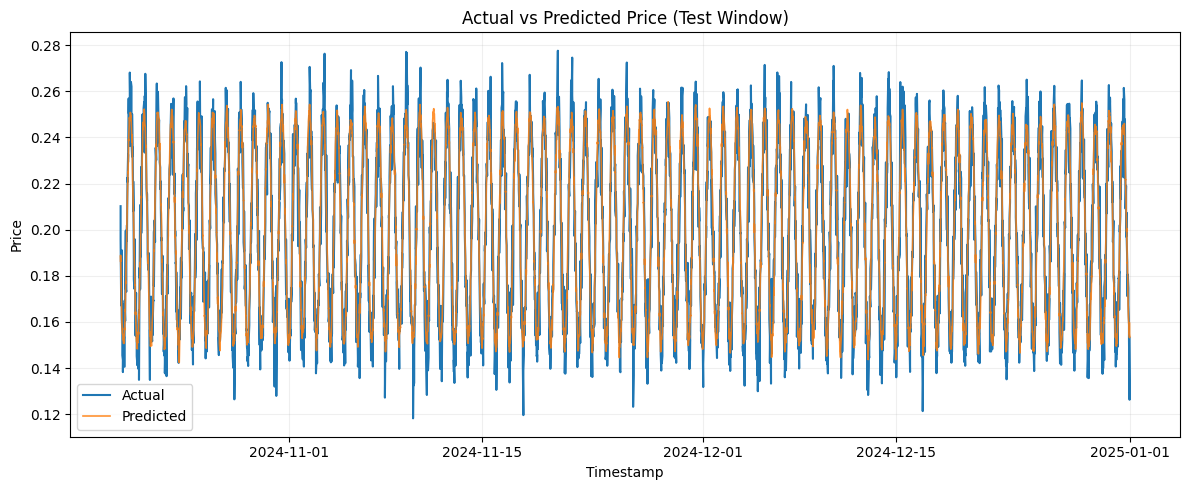

In [5]:
fig_actual_pred, ax = plt.subplots(figsize=(12, 5))
ax.plot(analysis_df["Timestamp"], analysis_df["Price_true"], label="Actual", linewidth=1.5)
ax.plot(analysis_df["Timestamp"], analysis_df["Price_pred"], label="Predicted", linewidth=1.2, alpha=0.85)
ax.set_title("Actual vs Predicted Price (Test Window)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Plot Residuals and Error Distribution
Inspect residuals over time and the error distribution.

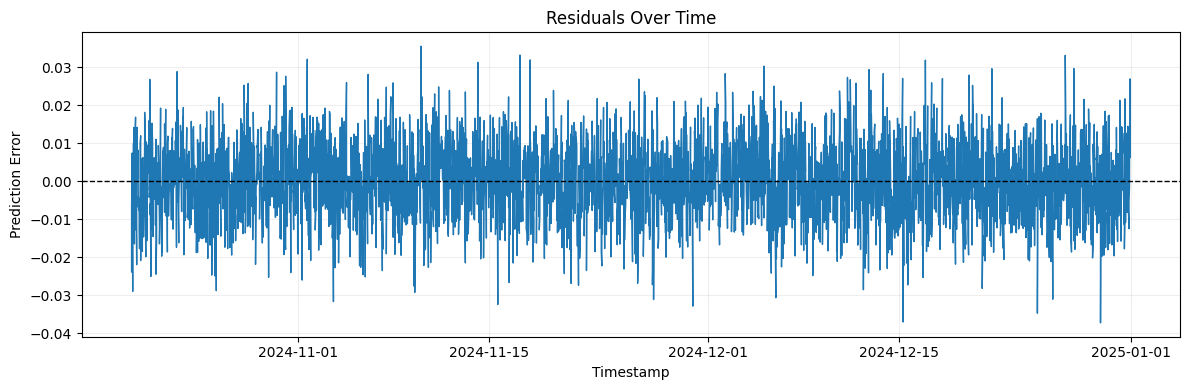

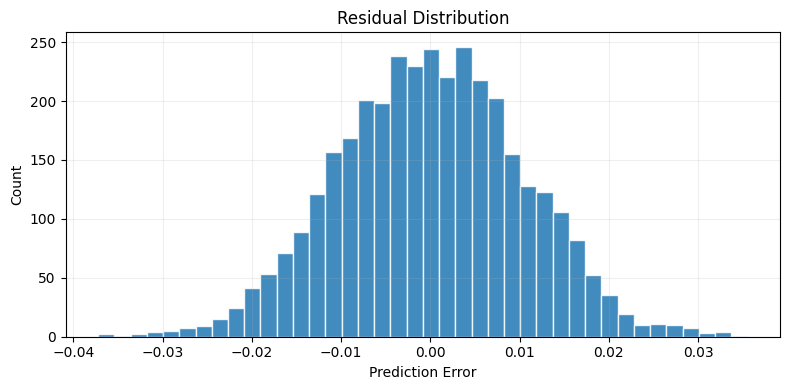

In [6]:
fig_residuals, ax = plt.subplots(figsize=(12, 4))
ax.plot(analysis_df["Timestamp"], analysis_df["Residual"], linewidth=1.0)
ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
ax.set_title("Residuals Over Time")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Prediction Error")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

fig_hist, ax = plt.subplots(figsize=(8, 4))
ax.hist(analysis_df["Residual"].dropna(), bins=40, edgecolor="white", alpha=0.85)
ax.set_title("Residual Distribution")
ax.set_xlabel("Prediction Error")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Plot Feature Importance
Visualize the top model features by importance.

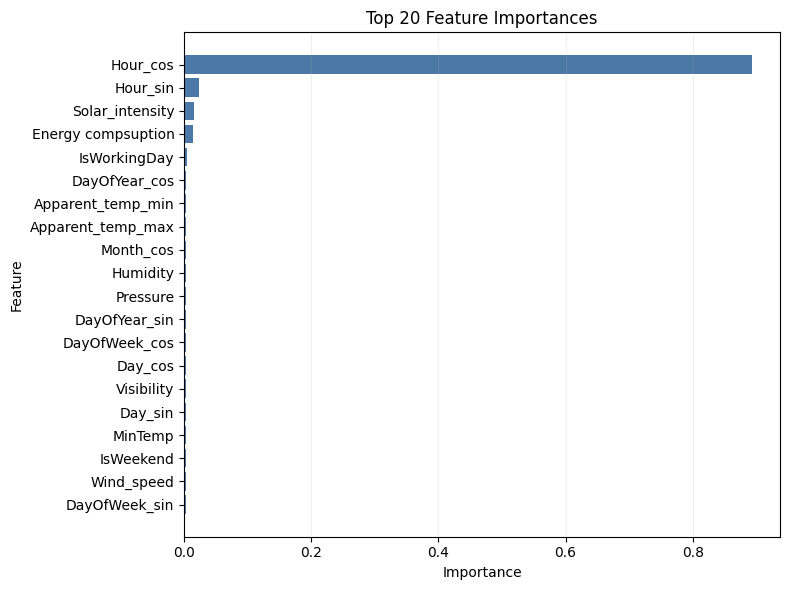

In [7]:
importance_df = pd.read_csv(feature_importance_path)
top_n = 20
plot_df = importance_df.head(top_n).iloc[::-1]

fig_importance, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df["feature"], plot_df["importance"], color="#4C78A8")
ax.set_title(f"Top {top_n} Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Save Figures to Disk
Write all generated figures into a Visualization folder.

In [8]:
viz_dir = prediction_dir / "Visualization"
viz_dir.mkdir(parents=True, exist_ok=True)

figures = {
    "actual_vs_predicted.png": fig_actual_pred,
    "residuals_over_time.png": fig_residuals,
    "residual_distribution.png": fig_hist,
    "feature_importance.png": fig_importance,
}

for name, fig in figures.items():
    fig.savefig(viz_dir / name, dpi=150)

viz_dir

WindowsPath('c:/Users/rkale/OneDrive/Documentos/VStudio/GitHub/Gitlab/GroupProject/25-26_CE903-SP_team03/Prediction/Visualization')